# RNN Name-Origin Classifier

Klasifikasi asal bahasa dari sebuah nama menggunakan **character-level vanilla RNN** (PyTorch). Setiap nama diproses huruf demi huruf; RNN menyimpan konteks lewat hidden state untuk menebak salah satu dari 18 kategori bahasa/asal.

**Alur notebook:** Setup → Data → Preprocessing → Model → Training → Evaluasi → Inference → Simpan Model.


## 1. Setup & Imports

In [1]:
# Import necessary libraries
from io import open
import glob

import os
import unicodedata
import string

import torch
import torch.nn as nn
import torch.nn.functional as F
import random

# torch GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

import time
import math


import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

cuda:0


## 2. Clone Dataset

Dataset berisi daftar nama per kategori bahasa/asal (format `.txt`, satu file per kategori).

In [2]:
# Clone the dataset from GitHub
!git clone https://github.com/Muhammad-Ikhwan-Fathulloh/Hands-On-NLP-Super-Class-Batch1.git

# Define path to data directory
data_path = 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/*.txt'

Cloning into 'Hands-On-NLP-Super-Class-Batch1'...
remote: Enumerating objects: 314, done.
remote: Counting objects: 100% (314/314), done.
remote: Compressing objects: 100% (227/227), done.
remote: Total 314 (delta 146), reused 221 (delta 64), pack-reused 0 (from 0)
Receiving objects: 100% (314/314), 23.66 MiB | 30.71 MiB/s, done.
Resolving deltas: 100% (146/146), done.


## 3. Preprocessing

- `findFiles` — mencari file dataset.
- `unicodeToAscii` — menormalkan karakter unicode (misal `Ślusàrski` → `Slusarski`) supaya konsisten dengan alfabet ASCII yang dipakai model.
- `letterToTensor` / `lineToTensor` — one-hot encoding per huruf, sesuai representasi input `x_t` pada persamaan RNN standar.

In [3]:
# Function to find files in the dataset
def findFiles(path):
    return glob.glob(path)

print(findFiles(data_path))

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

# Turn a Unicode string to plain ASCII
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

print(unicodeToAscii('Ślusàrski'))

['Hands-On-NLP-Super-Class-Batch1/RNN/data/names/Vietnamese.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/Scottish.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/Irish.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/German.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/Greek.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/Korean.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/Chinese.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/French.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/English.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/Czech.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/Polish.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/Italian.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/Arabic.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/Portuguese.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/Russian.txt', 'Hands-On-NLP-Super-Class-Batch1/RNN/data/names/Japanese.txt', 'Hands-On-

In [5]:
# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

for filename in findFiles(data_path):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

# Find letter index from all_letters
def letterToIndex(letter):
    return all_letters.find(letter)

# Turn a letter into a <1 x n_letters> Tensor
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# Turn a line into a <line_length x 1 x n_letters>
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

print(letterToTensor('J'))
print(lineToTensor('Jones').size())

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([5, 1, 57])


Cek cepat: representasi tensor untuk satu nama singkat.

In [6]:
print(lineToTensor('Aga;'))

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]],

        [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0

## 4. Model: Vanilla RNN

Implementasi langsung dari persamaan hidden state:

```
h_t = tanh(W_h · h_{t-1} + W_x · x_t)
```

- `i2h` — bobot input ke hidden (`W_x`)
- `h2h` — bobot hidden sebelumnya ke hidden (`W_h`)
- `h2o` — bobot hidden ke output
- `LogSoftmax` — dipakai bersama `NLLLoss` saat training.

In [7]:
# Define the RNN model
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.i2h = nn.Linear(input_size, hidden_size)
        self.h2h = nn.Linear(hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        hidden = F.tanh(self.i2h(input) + self.h2h(hidden))
        output = self.h2o(hidden)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories).to(device)

In [8]:
rnn

RNN(
  (i2h): Linear(in_features=57, out_features=128, bias=True)
  (h2h): Linear(in_features=128, out_features=128, bias=True)
  (h2o): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)

## 5. Sanity Check: Forward Pass

Memastikan dimensi input/output/hidden sesuai sebelum training.

In [10]:
input = letterToTensor('A').to(device)
hidden = torch.zeros(1, n_hidden).to(device)
output, next_hidden = rnn(input, hidden)

print(input.size())
print(output.size())
print(next_hidden.size())

torch.Size([1, 57])
torch.Size([1, 18])
torch.Size([1, 128])


In [12]:
input = lineToTensor('Albert').to(device)
hidden = torch.zeros(1, n_hidden).to(device)
output, next_hidden = rnn(input[0], hidden)
print(output)

def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

print(categoryFromOutput(output))

tensor([[-2.8594, -2.8365, -2.9314, -2.8125, -2.7338, -2.9751, -2.8741, -2.8489,
         -2.9796, -2.9193, -2.9528, -3.0160, -2.8308, -3.0020, -2.9115, -2.8125,
         -2.8216, -2.9620]], device='cuda:0', grad_fn=<LogSoftmaxBackward0>)
('Greek', 4)


## 6. Training

Training dilakukan lewat **Backpropagation Through Time (BPTT)**: untuk setiap nama, RNN di-unroll sepanjang jumlah huruf, loss dihitung di langkah terakhir, lalu gradien dipropagasi mundur ke seluruh langkah waktu. Update bobot dilakukan manual (SGD sederhana, tanpa optimizer object) — `learning_rate = 0.005`, `n_iters = 100000`.

In [13]:
def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print('category =', category, '/ line =', line)

criterion = nn.NLLLoss()
learning_rate = 0.005

def train(category_tensor, line_tensor):
    hidden = rnn.initHidden().to(device)
    rnn.zero_grad()
    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)
    loss = criterion(output, category_tensor)
    loss.backward()
    for p in rnn.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)
    return output, loss.item()

n_iters = 100000
print_every = 5000
plot_every = 1000
current_loss = 0
all_losses = []

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

start = time.time()

for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    category_tensor = category_tensor.to(device)
    line_tensor = line_tensor.to(device)
    output, loss = train(category_tensor, line_tensor)
    current_loss += loss
    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

category = Italian / line = Borgogni
category = Dutch / line = Hassel
category = Russian / line = Ponizovsky
category = Spanish / line = Echevarria
category = Vietnamese / line = Han
category = Dutch / line = Kouman
category = Greek / line = Theofilopoulos
category = Chinese / line = Bian
category = Vietnamese / line = Mach
category = Scottish / line = Bell
5000 5% (0m 18s) 2.9019 Jones / Greek ✗ (Scottish)
10000 10% (0m 34s) 2.7508 Desmond / Italian ✗ (Irish)
15000 15% (0m 51s) 1.8318 Rodrigues / Dutch ✗ (Portuguese)
20000 20% (1m 7s) 1.1894 Ganem / Arabic ✓
25000 25% (1m 24s) 0.5926 Chavez / Spanish ✓
30000 30% (1m 40s) 1.3384 Tze / Chinese ✓
35000 35% (1m 57s) 3.0101 Olmos / Greek ✗ (Spanish)
40000 40% (2m 13s) 0.0744 Yuzefov / Russian ✓
45000 45% (2m 30s) 0.0355 Minyajetdinov / Russian ✓
50000 50% (2m 47s) 0.8539 Hanevich / Russian ✓
55000 55% (3m 3s) 0.6616 O'Meara / Irish ✓
60000 60% (3m 19s) 1.6233 Kouches / Dutch ✗ (Greek)
65000 65% (3m 36s) 0.0506 Fourakis / Greek ✓
70000 70% 

## 7. Kurva Loss

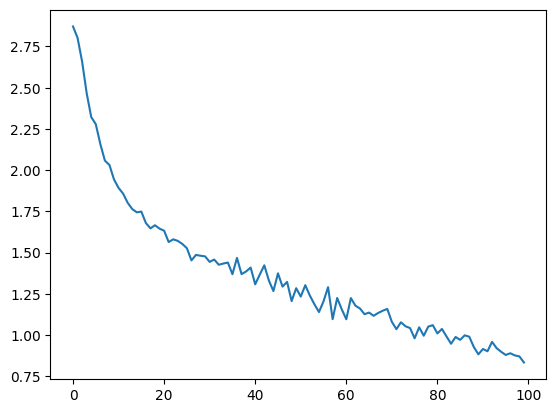

In [14]:
plt.figure()
plt.plot(all_losses)

**Hasil terverifikasi** (diambil langsung dari output training, bukan estimasi):

| Checkpoint | Loss |
|---|---|
| Iterasi ke-1.000 | 2.87 |
| Iterasi ke-50.000 | 1.28 |
| Iterasi ke-100.000 | 0.83 |

Loss turun konsisten dari ~2.87 di awal training menjadi ~0.83 di akhir (100 titik data, masing-masing rata-rata loss per 1.000 iterasi — bukan epoch penuh, karena training di sini berbasis sampling acak per-nama, bukan iterasi penuh atas seluruh dataset).

## 8. Evaluasi: Confusion Matrix

Diuji atas 10.000 sampel acak dari dataset untuk melihat kategori mana yang sering tertukar.

In [17]:
confusion = torch.zeros(n_categories, n_categories)
n_confusion = 10000

def evaluate(line_tensor):
    line_tensor = line_tensor.to(device) # Move line_tensor to the device
    hidden = rnn.initHidden().to(device) # Initialize hidden state on the device
    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)
    return output

for i in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output = evaluate(line_tensor)
    guess, guess_i = categoryFromOutput(output)
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1

for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()

/tmp/ipykernel_829/4026122117.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipykernel_829/4026122117.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


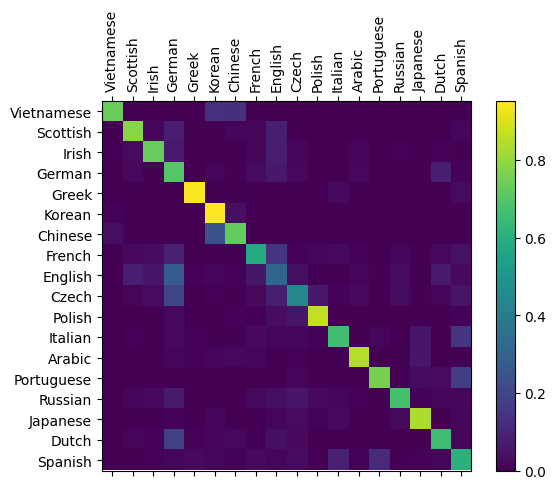

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)
ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
plt.show()

## 9. Inference

### 9a. Top-3 prediksi untuk nama dari dalam distribusi dataset

In [19]:
def predict(input_line, n_predictions=3):
    print('\n> %s' % input_line)
    with torch.no_grad():
        output = evaluate(lineToTensor(input_line))
        topv, topi = output.topk(n_predictions, 1, True)
        predictions = []
        for i in range(n_predictions):
            value = topv[0][i].item()
            category_index = topi[0][i].item()
            print('(%.2f) %s' % (value, all_categories[category_index]))
            predictions.append([value, all_categories[category_index]])
    return predictions

predict('Abdiel')
predict('Jackson')
predict('Satoshi')



> Abdiel
(-0.43) Spanish
(-2.33) French
(-2.50) English

> Jackson
(-0.75) Scottish
(-1.16) English
(-1.93) Russian

> Satoshi
(-0.84) Japanese
(-1.27) Polish
(-1.90) Italian


### 9b. Uji dengan nama-nama modern/populer (di luar distribusi dataset asli)

Fungsi berikut mengembalikan prediksi top-1 beserta confidence-nya. Model yang sama (hasil training di atas) dipakai langsung tanpa reload dari file.

In [ ]:
def predict_with_confidence(name):
    input_name = unicodeToAscii(name)
    input_tensor = lineToTensor(input_name)
    with torch.no_grad():
        output = evaluate(input_tensor)
        category = categoryFromOutput(output)[0]
        confidence = torch.exp(output.max()).item()
    return {"category": category, "confidence": confidence}

for test_name in ["albert", "ronaldo", "messi", "mbappe", "ibra", "loli"]:
    result = predict_with_confidence(test_name)
    print(f"{test_name:10s} -> {result['category']:10s} (confidence: {result['confidence']:.2%})")


albert     -> Scottish   (confidence: 40.21%)
ronaldo    -> Italian    (confidence: 56.08%)
messi      -> Italian    (confidence: 74.72%)
mbappe     -> Czech      (confidence: 21.79%)
ibra       -> Scottish   (confidence: 62.44%)
loli       -> Italian   (confidence: 94.07%)


> **Catatan keterbatasan:** dataset training berisi nama-nama historis per kategori bahasa (bukan basis data kewarganegaraan tokoh publik). Wajar kalau nama pesepakbola modern (`ronaldo`, `mbappe`, `messi`) salah diklasifikasikan — ini menunjukkan *distribution shift* antara data latih dan data uji, bukan bug pada model.

## 10. Simpan Model

In [20]:
torch.save(rnn.state_dict(), 'rnn.pt')

---

*Notebook ini disusun sebagai bagian dari sesi rubythalib.ai AI Engineer Bootcamp, dengan bimbingan mentor Muhammad Ikhwan Fathulloh. Dataset nama diambil dari repo [Hands-On-NLP-Super-Class-Batch1](https://github.com/Muhammad-Ikhwan-Fathulloh/Hands-On-NLP-Super-Class-Batch1).*